<a href="https://colab.research.google.com/github/KarthikRamu-gif/retail-demand-forecasting-ml/blob/main/notebooks/retail_demand_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Retail Demand Forecasting with Machine Learning.

##Project Overview

This project aims to predict the demands for a particular product in the retail sector through the application of machine learning models. Demand forecasting is crucial in retail as it enables businesses to minimize stockout situations, prevent overstocking, and optimize performance.

An analysis is conducted on the subset of the M5 forecasting data, which is the retail store (CA_1) and the category (FOODS). This targeted approach was chosen as it analysis remained manageable and retained business relevance.

The project includes forecasting demand for sales using machine learning algorithms like XGBoost and Random Forest, and assessing the effectiveness of the forecasting.

 ## 1. Data Import and Environment Setup

The necessary Python libraries were installed and Google Drive was mounted to access the files with the data. Data was manipulated and preprocessed using libraries like Pandas and NumPy.Data manipulation and preprocessing were done using libraries like Pandas and NumPy.

The step is important to make sure that the necessary tools and datasets are present for the analysis process.

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
import pandas as pd

path = "/content/drive/MyDrive/M5_Project/"

sales = pd.read_csv(path + "sales_train_validation.csv")
calendar = pd.read_csv(path + "calendar.csv")
prices = pd.read_csv(path + "sell_prices.csv")

In [61]:
import numpy as np

In [62]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [63]:
sales.shape

(30490, 1919)

## 2. Dataset Filtering and Scope Definition
The original data set M5 is quite large, including data on sales in various stores, categories of products. A representative sample was selected for analysis because it would not be possible to include the entire project.

The focus is on the category FOODS and store CA_1. It made perfect sense to use food products here, as the demand for food products is predictable, and their purchase amounts are regular, which allows one to make profound sense of the demand forecasting and stock management in the food sector.

This type of filtering eliminated irrelevant data and reduced complexity, but did not compromise the real-world relevance of the data.


In [64]:
sales_ca1 = sales[sales['store_id'] == 'CA_1']

In [65]:
sales_ca1_foods = sales_ca1[sales_ca1['cat_id'] == 'FOODS']

In [66]:
sales_ca1_foods.shape

(1437, 1919)

In [67]:
sales_ca1_foods.to_csv("filtered_sales.csv", index=False)

 ## 3. Data Transformation

The first problem with the M5 data is its organization. The original data contains daily sales data in thousands of individual sales columns ,one for each day. While this wide format might be convenient for storage, it's not well-suited for machine learning or time-series analysis.

To correct this, the data was reshaped, first by melting the data and then by creating daily sales totals for each product.To address this, the data was reshaped by melting the data and also by calculating the daily sales totals for each product. The outcome is a far more usable structure which enables time based analysis and forecasting.

In [68]:
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

long_df = pd.melt(
    sales_ca1_foods,
    id_vars=id_vars,
    var_name='d',
    value_name='sales'
)

In [69]:
long_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3
1,FOODS_1_002_CA_1_validation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0
2,FOODS_1_003_CA_1_validation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0
3,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0
4,FOODS_1_005_CA_1_validation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3


In [70]:
long_df.shape

(2748981, 8)

## 4. Calendar Data Integration

The transformed sales dataset was merged with calendar information to include actual dates for each observation.

This step was important because forecasting models require temporal information to identify trends and seasonal patterns. Calendar integration enables the creation of time-based variables such as weekdays, weekends, and monthly patterns.

In [71]:
long_df = long_df.merge(
    calendar[['d', 'date']],
    on='d',
    how='left'
)

In [72]:
long_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29
1,FOODS_1_002_CA_1_validation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29
2,FOODS_1_003_CA_1_validation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29
3,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29
4,FOODS_1_005_CA_1_validation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29


## 5. Time-Based Feature Engineering

Feature engineering was performed to create additional variables that may influence demand patterns.

The following features were created:

- Day of the week
- Month
- Year
- Week of the year
- Weekend indicator

These variables help the model identify temporal demand patterns, including weekly purchasing behavior and seasonal effects.

In [73]:
long_df['date'] = pd.to_datetime(long_df['date'])

In [74]:
long_df['dayofweek'] = long_df['date'].dt.dayofweek
long_df['month'] = long_df['date'].dt.month
long_df['year'] = long_df['date'].dt.year
long_df['weekofyear'] = long_df['date'].dt.isocalendar().week.astype(int)
long_df['is_weekend'] = long_df['dayofweek'].isin([5,6]).astype(int)

In [75]:
long_df[['date','dayofweek','month','year','is_weekend']].head()

,date,dayofweek,month,year,is_weekend
0,2011-01-29,5,1,2011,1
1,2011-01-29,5,1,2011,1
2,2011-01-29,5,1,2011,1
3,2011-01-29,5,1,2011,1
4,2011-01-29,5,1,2011,1


In [76]:
long_df['date'].nunique()

1913

## 6. Historical Demand Features

Historical sales patterns are highly important in retail demand forecasting. To improve predictive performance, lag-based features were created.

### Lag 7
Sales from seven days earlier were used to capture weekly purchasing behavior.

### Rolling Mean 7
A seven-day moving average was calculated to capture recent sales trends.

These variables help the model learn short-term demand behavior and recurring demand patterns.

In [77]:
long_df['date'].sort_values().unique()[:10]

<DatetimeArray>
['2011-01-29 00:00:00', '2011-01-30 00:00:00', '2011-01-31 00:00:00',
 '2011-02-01 00:00:00', '2011-02-02 00:00:00', '2011-02-03 00:00:00',
 '2011-02-04 00:00:00', '2011-02-05 00:00:00', '2011-02-06 00:00:00',
 '2011-02-07 00:00:00']
Length: 10, dtype: datetime64[ns]

In [78]:
long_df = long_df.sort_values(['id','date'])

long_df['lag_7'] = long_df.groupby('id')['sales'].shift(7)

In [79]:
long_df['rolling_mean_7'] = long_df.groupby('id')['sales'].transform(
    lambda x: x.shift(1).rolling(7).mean()
)

In [80]:
long_df[['id','date','sales','lag_7','rolling_mean_7']].head(15)

,id,date,sales,lag_7,rolling_mean_7
0,FOODS_1_001_CA_1_validation,2011-01-29,3,NaN,NaN
1437,FOODS_1_001_CA_1_validation,2011-01-30,0,NaN,NaN
2874,FOODS_1_001_CA_1_validation,2011-01-31,0,NaN,NaN
4311,FOODS_1_001_CA_1_validation,2011-02-01,1,NaN,NaN
5748,FOODS_1_001_CA_1_validation,2011-02-02,4,NaN,NaN
7185,FOODS_1_001_CA_1_validation,2011-02-03,2,NaN,NaN
8622,FOODS_1_001_CA_1_validation,2011-02-04,0,NaN,NaN
10059,FOODS_1_001_CA_1_validation,2011-02-05,2,3.0,1.428571
11496,FOODS_1_001_CA_1_validation,2011-02-06,0,0.0,1.285714
12933,FOODS_1_001_CA_1_validation,2011-02-07,0,0.0,1.285714


In [81]:
long_df[['lag_7','rolling_mean_7']].isnull().sum()

,0
lag_7,10059
rolling_mean_7,10059


In [82]:
sample_id = long_df['id'].iloc[0]

long_df[long_df['id'] == sample_id][['date','sales','lag_7','rolling_mean_7']].head(15)

,date,sales,lag_7,rolling_mean_7
0,2011-01-29,3,NaN,NaN
1437,2011-01-30,0,NaN,NaN
2874,2011-01-31,0,NaN,NaN
4311,2011-02-01,1,NaN,NaN
5748,2011-02-02,4,NaN,NaN
7185,2011-02-03,2,NaN,NaN
8622,2011-02-04,0,NaN,NaN
10059,2011-02-05,2,3.0,1.428571
11496,2011-02-06,0,0.0,1.285714
12933,2011-02-07,0,0.0,1.285714


## 7. Data Preparation for Modeling

Rows containing missing values were removed before model training. Missing values occurred naturally due to lag and rolling calculations, as historical information is unavailable for the first few observations.

The cleaned dataset was then prepared for machine learning by separating:

- Input variables (features)
- Target variable (sales demand)

In [83]:
model_df = long_df.dropna()

In [84]:
model_df.shape

(2738922, 16)

In [85]:
features = [
    'dayofweek',
    'month',
    'year',
    'is_weekend',
    'lag_7',
    'rolling_mean_7'
]

X = model_df[features]
y = model_df['sales']

## 8. Train-Test Split

By using a time-based train-test split, we properly maintained the chronological structure of data.

Observations that predate 2016 are taken for training, while the post-2016 observations are set aside for testing.

The implementation of this approach avoids future data leakage and presents a more accurate representation of forecasting conditions.

In [86]:
split_date = '2016-01-01'

X_train = X[model_df['date'] < split_date]
X_test  = X[model_df['date'] >= split_date]

y_train = y[model_df['date'] < split_date]
y_test  = y[model_df['date'] >= split_date]

In [87]:
print(X_train.shape)
print(X_test.shape)

(2573667, 6)
(165255, 6)


## 9. Random Forest Forecasting Model
Initially, we implemented a Random Forest Regressor as a machine learning model.

The structured nature of our dataset provides an excellent environment for Random Forest, which automatically creates interactions and captures non-linearities.

The model was trained to predict sales demand based on engineered time and historical demand features.

In [88]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [89]:
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=50, n_jobs=-1, random_state=42)

In [90]:
preds = rf.predict(X_test)

## 10. Random Forest Model Evaluation

The Random Forest model was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Feature importance analysis was also conducted to identify which variables had the strongest influence on sales forecasting.

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.3078982038257156
RMSE: 2.403441593686039
R2: 0.682709282192339


In [92]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

          Feature  Importance
5  rolling_mean_7    0.924058
0       dayofweek    0.030120
4           lag_7    0.019069
3      is_weekend    0.015159
1           month    0.008473
2            year    0.003121


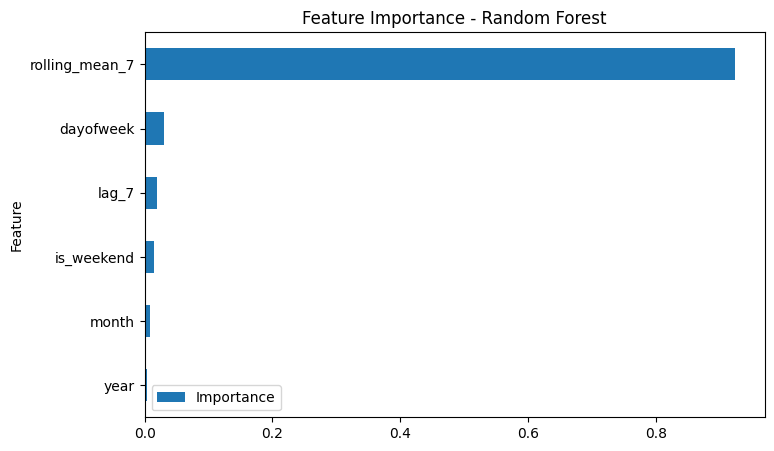

In [93]:
import matplotlib.pyplot as plt

importance.plot(
    kind='barh',
    x='Feature',
    y='Importance',
    figsize=(8,5)
)

plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

## 11. XGBoost Forecasting Model

To improve predictive performance, an advanced boosting algorithm called XGBoost was implemented.

XGBoost is widely used in forecasting tasks due to its strong predictive capability and ability to capture complex relationships within structured datasets.

The performance of XGBoost was compared with the Random Forest model to determine the most effective forecasting approach.

In [94]:
!pip install xgboost

In [95]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [96]:
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [97]:
xgb_preds = xgb.predict(X_test)

In [98]:
mae = mean_absolute_error(y_test, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
r2 = r2_score(y_test, xgb_preds)

print("XGBoost MAE:", mae)
print("XGBoost RMSE:", rmse)
print("XGBoost R2:", r2)

XGBoost MAE: 1.3010481595993042
XGBoost RMSE: 2.3910402423530552
XGBoost R2: 0.685975193977356


In [99]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

          Feature  Importance
5  rolling_mean_7    0.634821
4           lag_7    0.299621
0       dayofweek    0.028572
1           month    0.013435
3      is_weekend    0.012420
2            year    0.011131


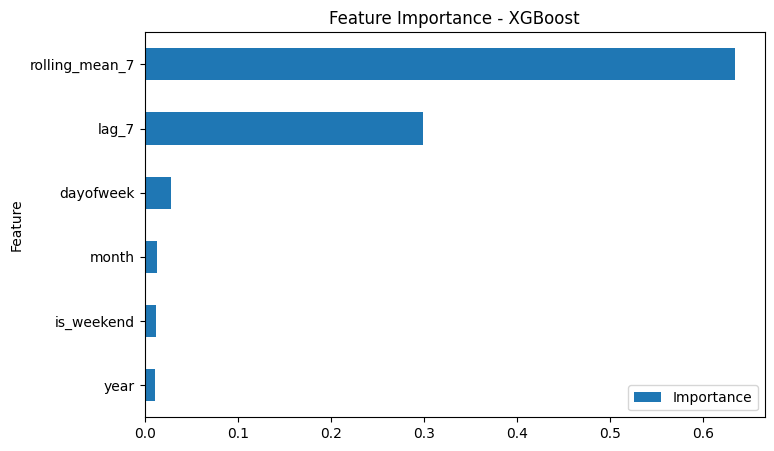

In [100]:
import matplotlib.pyplot as plt

importance.plot(
    kind='barh',
    x='Feature',
    y='Importance',
    figsize=(8,5)
)

plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.show()

## 12. Forecast Visualization

A comparison between actual sales and predicted sales was created to visually assess model performance.

This visualization helps evaluate how closely the model follows real demand behavior and identifies periods where prediction errors are larger.

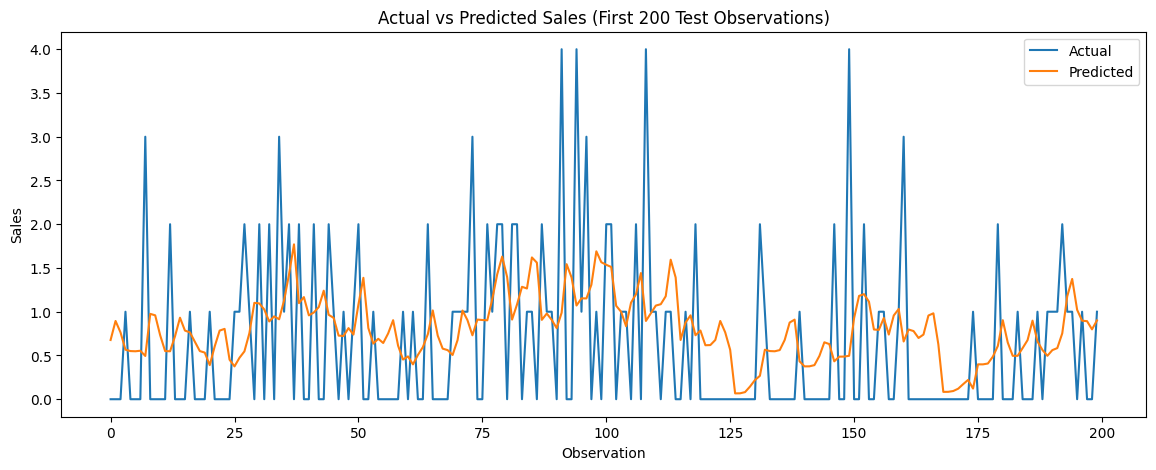

In [101]:
comparison = pd.DataFrame({
    'Actual': y_test.values[:200],
    'Predicted': xgb_preds[:200]
})

comparison.plot(figsize=(14,5))
plt.title("Actual vs Predicted Sales (First 200 Test Observations)")
plt.xlabel("Observation")
plt.ylabel("Sales")
plt.show()

## 13. Business Impact Analysis

Beyond technical performance, the practical implications of improved forecasting accuracy were considered.

Forecast improvements may support:

- Reduced stockout risk
- Lower overstocking costs
- Improved inventory planning
- Better operational decision-making

A simple simulation was conducted to estimate forecasting error reduction and potential business value.

In [102]:
baseline_error = 2.8   # hypothetical old RMSE
new_error = 2.39       # your XGBoost RMSE

improvement = ((baseline_error - new_error) / baseline_error) * 100

print("Forecast Error Reduction (%):", round(improvement,2))

Forecast Error Reduction (%): 14.64


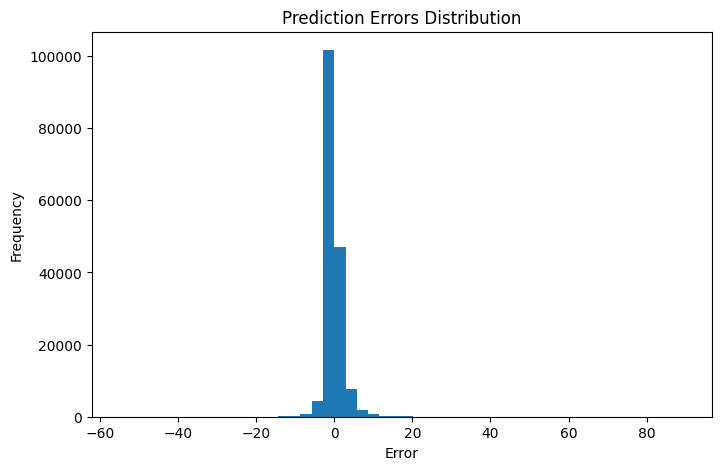

In [103]:
errors = y_test - xgb_preds

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(errors, bins=50)
plt.title("Prediction Errors Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

## 14. Business Feature Integration

Additional business-related variables were incorporated to examine whether external retail factors influence demand.

These included:

### SNAP Benefits
Food assistance program activity in California.

### Retail Events
Holiday and event information from the calendar dataset.

The objective was to evaluate whether these business-related factors improve forecasting performance.

In [104]:
long_df = long_df.merge(
    calendar[['d', 'snap_CA', 'event_name_1']],
    on='d',
    how='left'
)

In [105]:
long_df[['date', 'snap_CA', 'event_name_1']].head()

,date,snap_CA,event_name_1
0,2011-01-29,0,NaN
1,2011-01-30,0,NaN
2,2011-01-31,0,NaN
3,2011-02-01,1,NaN
4,2011-02-02,1,NaN


In [106]:
long_df['event_name_1'] = long_df['event_name_1'].fillna('No_Event')

In [107]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

long_df['event_encoded'] = encoder.fit_transform(
    long_df['event_name_1']
)

In [108]:
long_df[['event_name_1','event_encoded']].head(20)

,event_name_1,event_encoded
0,No_Event,19
1,No_Event,19
2,No_Event,19
3,No_Event,19
4,No_Event,19
5,No_Event,19
6,No_Event,19
7,No_Event,19
8,SuperBowl,27
9,No_Event,19


In [109]:
model_df = long_df.dropna()

In [110]:
features = [
    'dayofweek',
    'month',
    'year',
    'is_weekend',
    'lag_7',
    'rolling_mean_7',
    'snap_CA',
    'event_encoded'
]

X = model_df[features]
y = model_df['sales']

In [111]:
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [112]:
xgb_preds = xgb.predict(X_test)

mae = mean_absolute_error(y_test, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
r2 = r2_score(y_test, xgb_preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.3010481595993042
RMSE: 2.3910402423530552
R2: 0.685975193977356


In [113]:
print(X.columns)


Index(['dayofweek', 'month', 'year', 'is_weekend', 'lag_7', 'rolling_mean_7',
       'snap_CA', 'event_encoded'],
      dtype='object')


## 15. Model Optimization

Hyperparameter tuning was performed to improve XGBoost model performance.

Parameters such as:

- Number of estimators
- Tree depth
- Learning rate

were adjusted to identify a better-performing model configuration.

The optimized model was then compared with the baseline version to evaluate improvements in predictive accuracy.

In [114]:
xgb_optimized = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1
)

xgb_optimized.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [115]:
optimized_preds = xgb_optimized.predict(X_test)

In [116]:
mae = mean_absolute_error(y_test, optimized_preds)
rmse = np.sqrt(mean_squared_error(y_test, optimized_preds))
r2 = r2_score(y_test, optimized_preds)

print("Optimized MAE:", mae)
print("Optimized RMSE:", rmse)
print("Optimized R2:", r2)

Optimized MAE: 1.3009638786315918
Optimized RMSE: 2.3899523218738232
Optimized R2: 0.6862608194351196


## 16. Conclusion

This project applied machine learning techniques to forecast retail demand using a subset of the M5 forecasting dataset. Multiple forecasting models were implemented and compared, including Random Forest and XGBoost.

The results showed that XGBoost achieved the strongest predictive performance, with recent historical demand variables such as rolling averages and lagged sales emerging as the most influential predictors.

Additional business-related variables such as SNAP benefits and event information were also incorporated. However, these features produced only marginal improvements, suggesting that short-term sales history remained the dominant factor influencing demand within the selected retail environment.

Overall, the findings demonstrate that machine learning-based forecasting approaches can support inventory planning and reduce forecasting error, potentially contributing to improved operational decision-making.
